<a href="https://colab.research.google.com/github/LeLucasB12/Data-Analysis-Challenge/blob/main/dasa_2p08_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
data = pd.read_csv('team15_sports.csv')
data

,game_id,team,opponent,home_game,points_scored,points_allowed,attendance,season,day_of_week,weather,won
0,1,Team D,Team A,True,77,72,15446.0,Regular,Saturday,Indoor,True
1,2,Team F,Team F,True,84,59,13078.0,Regular,Tuesday,Indoor,True
2,3,Team F,Team C,True,77,74,16317.0,Regular,Wednesday,Cloudy,True
3,4,Team E,Team C,False,87,73,NaN,Regular,Saturday,Clear,True
4,5,Team C,Team A,True,95,82,18230.0,Regular,Monday,Cloudy,True
...,...,...,...,...,...,...,...,...,...,...,...
495,496,Team D,Team C,False,89,85,11278.0,Regular,Tuesday,Cloudy,True
496,497,Team C,Team B,True,103,99,13666.0,Regular,Thursday,Cloudy,True
497,498,Team A,Team B,False,92,86,12413.0,Playoffs,Monday,Clear,True
498,499,Team E,Team E,False,86,81,20143.0,Regular,Thursday,Clear,True


# Data Cleaning

In [ ]:
data = data.dropna()
data

,game_id,team,opponent,home_game,points_scored,points_allowed,attendance,season,day_of_week,weather,won
0,1,Team D,Team A,True,77,72,15446.0,Regular,Saturday,Indoor,True
1,2,Team F,Team F,True,84,59,13078.0,Regular,Tuesday,Indoor,True
2,3,Team F,Team C,True,77,74,16317.0,Regular,Wednesday,Cloudy,True
4,5,Team C,Team A,True,95,82,18230.0,Regular,Monday,Cloudy,True
5,6,Team C,Team E,True,92,81,14530.0,Regular,Thursday,Clear,True
...,...,...,...,...,...,...,...,...,...,...,...
495,496,Team D,Team C,False,89,85,11278.0,Regular,Tuesday,Cloudy,True
496,497,Team C,Team B,True,103,99,13666.0,Regular,Thursday,Cloudy,True
497,498,Team A,Team B,False,92,86,12413.0,Playoffs,Monday,Clear,True
498,499,Team E,Team E,False,86,81,20143.0,Regular,Thursday,Clear,True


# Question 1:
What is the win rate for home games vs away games?

In [ ]:
# Selecting home wins and away wins
home_wins = data[(data["home_game"] == True) & (data["won"] == True)].shape[0]
away_wins = data[(data["home_game"] == False) & (data["won"] == True)].shape[0]

# Sum of home and away wins
total_wins = home_wins + away_wins

# Calculation of percentages
home_pct = (home_wins / total_wins) * 100
away_pct = (away_wins / total_wins) * 100

# Output of percentages
print(f"Home win:{home_pct}%")
print(f"Away win: {away_pct}%")




Home win:49.45054945054945%
Away win: 50.54945054945055%


1. Rows are selected where home games are True and where "Won" column has the value "TRUE"
2. Rows are selected where home games are False (away games) and where the "Won"column has the value "TRUE"
3. Sum of total home wins and away wins occurs into total_wins
4. The calculation of the ration between (home wins / total wins) * 100 occurs (win rate formula)
5. The calculation of the ration between (away wins / total wins) * 100 occurs (win rate formula)
6. The output of home and away wins percentage is printed

# Question 2:
Which team has the best overall record?

First we create dictionaries to hold the data stratified into teams and the data from those that contains a win.

In [ ]:

win_data = data[data['won'] == True]
# Loading team overall games played
team_data = {
    'A': data[data['team'] == 'Team A'],
    'B': data[data['team'] == 'Team B'],
    'C': data[data['team'] == 'Team C'],
    'D': data[data['team'] == 'Team D'],
    'E': data[data['team'] == 'Team E'],
    'F': data[data['team'] == 'Team F']
}
# Loading team games won
team_win_data = {
    'A': win_data[win_data['team'] == 'Team A'],
    'B': win_data[win_data['team'] == 'Team B'],
    'C': win_data[win_data['team'] == 'Team C'],
    'D': win_data[win_data['team'] == 'Team D'],
    'E': win_data[win_data['team'] == 'Team E'],
    'F': win_data[win_data['team'] == 'Team F']
}
# Dividing the size of both to get the win rates
win_percentages = []
for win, total in zip(team_data, team_win_data):
  win_percentages.append(team_win_data[win].shape[0] / team_data[win].shape[0])

win_percentages

[0.6266666666666667,
 0.6,
 0.5735294117647058,
 0.5168539325842697,
 0.5131578947368421,
 0.45454545454545453]

We we find the teams have the following win rates: <br>
Team A : 62.67% <br>
Team B : 60.00% <br>
Team C : 57.35% <br>
Team D : 51.69% <br>
Team E : 51.32% <br>
Team F : 45.45% <br>

Therefore, Team A had the best win rate.



# Question 3:
How does attendance correlate with team performance?

ValueError: could not convert string to float: 'Team D'

# Question 4:
Do teams score more points on specific days of the week?

Monday Average : 85.24285714285715
Tuesday Average : 83.88235294117646
Wednesday Average : 82.43103448275862
Thursday Average : 84.6140350877193
Friday Average : 83.32835820895522
Saturday Average : 83.578125
Sunday Average : 84.87878787878788


<BarContainer object of 7 artists>

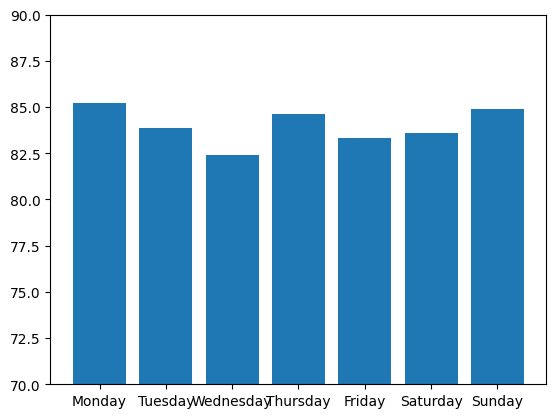

In [ ]:
# List of days to generate the data
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = {}

# Stratifying data by day played
for day in days:
  day_data[day] = data[data['day_of_week'] == day]
day_data['Monday']

# Cleaning up output
day_means = [day_data[day]['points_scored'].mean() for day in days]
day_means = [float(day_mean) for day_mean in day_means]

# Output
for day, mean in zip(days, day_means):
  print(f"{day} Average : {mean}")

plot = plt.bar(x= days, height=day_means)
plt.ylim(70,90)
plot

# Question 5:
What is the average point differential in wins vs. losses?

First we recall that a point differential as the following formula:
$ \Delta P = P_{scored} - P_{allowed} $

In [ ]:
# Creating differential with a pandas selector
differential_data = data.copy()
differential_data['points_differential'] = abs(differential_data['points_scored'] - differential_data['points_allowed'])
differential_data

# Calculating means
win_mean = differential_data[differential_data['won'] == True]['points_differential'].mean()
loss_mean = differential_data[differential_data['won'] == False]['points_differential'].mean()

# Outputting the data
print(f"""
  Point differential mean in wins: {win_mean}
  Point differential mean in loss: {loss_mean}
""")


  Point differential mean in wins: 14.759183673469387
  Point differential mean in loss: 12.453658536585365



# Question 6:
How do playoff games differ from the regular season games?

In [ ]:
# Selecting playoffs and regular season games
playoffs_data = data[data['season'] == 'Playoffs']
regular_season_data = data[data['season'] == 'Regular']

# Printing mean of key values for playoff games
print("--- Playoff Games ---")
print(f"Average points scored: {playoffs_data['points_scored'].mean():.2f}")
print(f"Average points allowed: {playoffs_data['points_allowed'].mean():.2f}")
print(f"Win rate: {playoffs_data['won'].mean() * 100:.2f}%")
print(f"Average attendance: {playoffs_data['attendance'].mean():.2f}")

# Printing mean of key values for regular games
print("\n--- Regular Season Games ---")
print(f"Average points scored: {regular_season_data['points_scored'].mean():.2f}")
print(f"Average points allowed: {regular_season_data['points_allowed'].mean():.2f}")
print(f"Win rate: {regular_season_data['won'].mean() * 100:.2f}%")
print(f"Average attendance: {regular_season_data['attendance'].mean():.2f}")


--- Playoff Games ---
Average points scored: 84.63
Average points allowed: 82.90
Win rate: 54.41%
Average attendance: 15121.84

--- Regular Season Games ---
Average points scored: 84.08
Average points allowed: 81.51
Win rate: 54.63%
Average attendance: 15151.05


1. The selection of "Playoffs" values are filtered from "season" column
2. The selection of "Regular" values are gathered from "season" column
3. The mean is calculated for "Playoffs" from "points_scored" (average points scored) and displayed
4. The mean is calculated for "Playoffs" from "points_allowed" (average poins allowed) and displayed
5. The mean is calculated for "Playoffs" from "won" (win rate) and displayed
6. The mean is calculated for "Playoffs" from "attendance" (average attendance) and displayed
7. The mean is calculated for "Regular" from "points_scored" (average points scored) and displayed
8. The mean is calculated for "Regular" from "points_allowed" (average poins allowed) and displayed
9. The mean is calculated for "Regular" from "won" (win rate) and displayed
10. The mean is calculated for "Regular" from "attendance" (average attendance) and displayed
